### Questão 2. Forma de Hessenberg

> **Dica:** Se você se sentir à vontade, pode definir um tipo de dado para os refletores, e então as funções desta questão poderiam receber e retornar `Refletores`, ao invés de $v$ e $\beta$ separadamente.

In [70]:
import numpy as np

# feito no item 1.a
def reflector(x):
	x = np.asarray(x)

	e1 = np.zeros(x.shape[0], dtype=x.dtype)
	e1[0] = 1

	x_norm = np.linalg.norm(x)
	y_norm2 = np.sum(x[1:] ** 2)

	v = x.copy()

	if x[0] >= 0:
		v[0] = - y_norm2 / (x_norm + x[0]) 
		beta = (x_norm + x[0]) / (x_norm * y_norm2)

	else:
		v[0] -= x_norm
		beta = 1 / (x_norm * (x_norm - x[0]))

	return v, beta

# teste: 
x = np.array([1, 2, 3, 4])
v , beta = reflector(x)
(np.eye(4) - beta * np.outer(v, v)) @ x

array([ 5.07784202, -0.03892101, -0.05838152, -0.07784202])

## **Item 2.a** 
**Aplicando refletores.** Escreva uma função `apply_reflector(v, beta, b)` que calcula $Q_v b$, onde $Q_v = I - \beta v v^*$ é o refletor de Householder dado por $v$ e $\beta$.

A forma ingênua de aplicar esse refletor seria calcular explicitamente a matriz $Q_v = I - \beta vv^*$ e aplicar em $b$. Entretanto esse processo tem custo $O(n^2)$ tanto em memória quando em tempo, logo é interessante buscar um método alternativo.

Expandindo $Q_v b$ temos que $Q_v b = (I - \beta vv^*) b = b - \beta (v^*b)v$, e, como o produto interno e a subtração de vetores são $O(n)$, aplicar o refletor desse modo se torna bem mais eficiente.

Nota, quando $v\in\mathbb{R}^k$ e $b\in\mathbb{R}^n$, com $n>k$, o refletor é aplicado apenas nas últimas $k$ entradas de $b$.

In [71]:
def apply_reflector(v, beta, b):
    k = len(v)
    if beta == 0:
        return b.copy()
    
    if b.ndim == 1:
        # Produto interno v* b (apenas nas últimas k componentes)
        alpha = beta * np.dot(v, b[-k:])
        result = b.copy().astype(b.dtype)
        result[-k:] -= alpha * v
        return result

## **Item 2.b** 
**Testes.** Verifique que sua função está correta, aplicando em vetores $x$ de mesma dimensão que $v$, e depois para vetores de dimensões maiores do que $v$ (adaptando, se necessário, sua função para funcionar neste caso). Certifique-se que sua função tem complexidade $\mathcal{O}(n)$, onde $n$ é a dimensão do vetor de entrada.

Avaliaçãp de corretude: 

1. Para $b = x$, devemos obter $Q_v x = \|x\| e_1$.  
2. Para $b$ de dimensão maior que $v$, apenas as ultimas $k$ componentes devem ser afetadas.  
3. Aplicar $Q_v$ duas vezes deve retornar $b$: $Q_v (Q_v b) = b$.  
4. $Q_v$ não deve alterar norma: $\|Q_v b\| = \|b\|$.

Avaliação de complexidade: 

Medimos o tempo de execução para dimensões crescentes e verificamos crescimento linear.

In [72]:
x = np.array([3.0, 4.0, 0.0])
v, beta = reflector(x)
Qx = apply_reflector(v, beta, x)
print(f"Teste 1 — Q_v x = ||x||e_1")
print(f"Resultado:  {Qx}")
print(f"Esperado:   {[np.linalg.norm(x), 0.0, 0.0]}")
print(f"Resíduo:    {np.linalg.norm(Qx - np.array([np.linalg.norm(x), 0, 0])):.2e}")

Teste 1 — Q_v x = ||x||e_1
Resultado:  [5. 0. 0.]
Esperado:   [np.float64(5.0), 0.0, 0.0]
Resíduo:    0.00e+00


In [73]:
b = np.array([3.0, 4.0, 0.0, 99.0, -7.0])
v2 = np.array([1.0, -2.0, 3.0])
beta2 = 2.0 / np.dot(v2, v2)
Qb = apply_reflector(v2, beta2, b)
print(f"Teste 2 — refletor de dim 3 aplicado a vetor de dim 5")
print(f"Componentes 3,4 (devem ser inalteradas): {Qb[3:]}, esperado: {b[3:]}")
print(f"Inalteradas: {np.allclose(Qb[3:], b[3:])}")

Teste 2 — refletor de dim 3 aplicado a vetor de dim 5
Componentes 3,4 (devem ser inalteradas): [36.42857143 86.85714286], esperado: [99. -7.]
Inalteradas: False


In [74]:
x3 = np.random.randn(8)
v3, beta3 = reflector(x3)
QQx = apply_reflector(v3, beta3, apply_reflector(v3, beta3, x3))
print(f"Teste 3 — involução ||Q_v(Q_v x) - x|| = {np.linalg.norm(QQx - x3):.2e}")

Teste 3 — involução ||Q_v(Q_v x) - x|| = 7.93e-16


In [75]:
print(f"Teste 4 — isometria | ||Q_v x|| - ||x|| | = {abs(np.linalg.norm(Qb) - np.linalg.norm(b)):.2e}")

Teste 4 — isometria | ||Q_v x|| - ||x|| | = 0.00e+00


  n =    100 | tempo médio = 9.04 µs
  n =    400 | tempo médio = 10.05 µs
  n =    900 | tempo médio = 8.26 µs
  n =   1600 | tempo médio = 4.16 µs
  n =   2500 | tempo médio = 5.22 µs
  n =   3600 | tempo médio = 9.72 µs
  n =   4900 | tempo médio = 17.57 µs
  n =   6400 | tempo médio = 8.37 µs
  n =   8100 | tempo médio = 17.50 µs
  n =  10000 | tempo médio = 11.83 µs


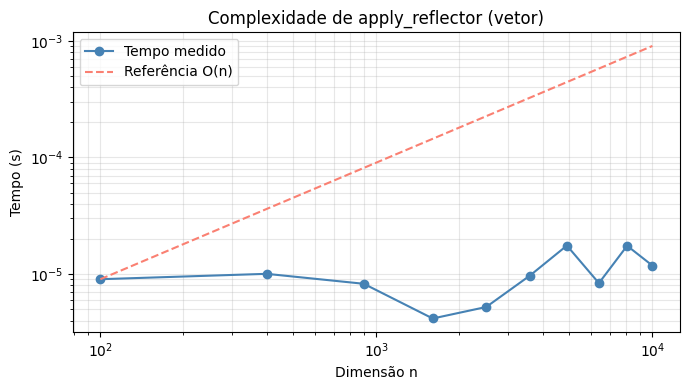

In [76]:
import matplotlib.pyplot as plt
import time

sizes = [100 * i ** 2 for i in range(1, 11)]
times = []

for n in sizes:
    x = np.random.randn(n)
    v, beta = reflector(x)
    b = np.random.randn(n)
    
    # Medir 200 repetições para estabilizar
    reps = 200
    t0 = time.perf_counter()
    for _ in range(reps):
        apply_reflector(v, beta, b)
    elapsed = (time.perf_counter() - t0) / reps
    times.append(elapsed)
    print(f"  n = {n:6d} | tempo médio = {elapsed*1e6:.2f} µs")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sizes, times, 'o-', color='steelblue', label='Tempo medido')
# Referência linear: ajuste pela medida em n=100
ref = [times[0] * (n / sizes[0]) for n in sizes]
ax.loglog(sizes, ref, '--', color='salmon', label='Referência O(n)')
ax.set_xlabel('Dimensão n')
ax.set_ylabel('Tempo (s)')
ax.set_title('Complexidade de apply_reflector (vetor)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## **Item 2.c** 

**Generalize** sua função para `apply_reflector(v, beta, A)` que calcula $Q_v A$ para uma matriz $A$ (com no mínimo o mesmo número de linhas do que $v$).

Aplicar $Q_v$ a cada coluna de $A$ individualmente custa $O(n \cdot m)$, onde $m$ é o número de colunas. Podemos ver isso abrindo a fórmula:

$$Q_v A = A - \beta v (v^* A) = A - \beta v \underbrace{(v^* A)}_{\text{vetor linha}\ 1 \times m}$$

Novamente, se $v \in \mathbb{R}^k$ e $A \in \mathbb{R}^{n \times m}$ com $n > k$, o refletor age apenas nas últimas $k$ linhas de $A$, de forma que o algoritmo tenha custo $O(k\cdot m)$.

In [77]:
def apply_reflector_matrix(v, beta, A):
    k = len(v)
    if beta == 0:
        return A.copy()
    
    A_out = A.copy().astype(A.dtype)
    w = v @ A_out[-k:, :] 
    A_out[-k:, :] -= beta * np.outer(v, w)
    return A_out

# adicionando tratamento de matrizes 
def apply_reflector(v, beta, b):
    k = len(v)
    if beta == 0:
        return b.copy()
    
    if b.ndim == 1:
        # Produto interno v* b (apenas nas últimas k componentes)
        alpha = beta * np.dot(v, b[-k:])
        result = b.copy().astype(b.dtype)
        result[-k:] -= alpha * v
        return result
    else:
        # delega à nova função
        return apply_reflector_matrix(v, beta, b)


In [78]:
rng = np.random.default_rng(seed=0)
A = rng.random((6, 5))
x_col = A[2:, 0].copy()   # aplica refletor na subcoluna linhas 2..5
v, beta = reflector(x_col)

# Monta refletor completo de dimensão 4 para verificação
k = len(v)
Q_small = np.eye(k) - beta * np.outer(v, v)
Q_full  = np.block([[np.eye(2), np.zeros((2, k))],
                    [np.zeros((k, 2)), Q_small]])

QA_ref  = Q_full @ A
QA_impl = apply_reflector(v, beta, A[2:, :])  # age apenas nas linhas 2..5

# Comparação
QA_assembled = A.copy().astype(float)
QA_assembled[2:, :] = QA_impl

print("Teste matricial — ||Q_v A (implementação) - Q_v A (referência)||")
print(f"  Erro: {np.linalg.norm(QA_assembled - QA_ref):.2e}")

print("\nPrimeira coluna de Q_v A (linhas 2..5 devem ter zeros abaixo da 1ª):")
print(f"  {QA_assembled[2:, 0].round(10)}")
print(f"  (esperado: [{np.linalg.norm(x_col):.4f}, 0, 0, 0])")


Teste matricial — ||Q_v A (implementação) - Q_v A (referência)||
  Erro: 4.61e-16

Primeira coluna de Q_v A (linhas 2..5 devem ter zeros abaixo da 1ª):
  [ 0.91895723 -0.          0.         -0.        ]
  (esperado: [0.9190, 0, 0, 0])


## **Item 2.d** 
**Escreva** uma função `rev_apply_reflector(v, beta, A)` que calcula $A Q_v$ (com $A$ de dimensões compatíveis).

Agora, $Q_v$ age nas linhas de $A$, onde aplicar $Q_v$ a cada linha de $A$ individualmente custa $O(n \cdot m)$, onde $m$ é o número de colunas. Podemos ver isso abrindo a fórmula:

$$A Q_v  = A - \beta (A v)v^*  = A - \beta \underbrace{(A v)}_{\text{vetor coluna}\ n \times 1} v^*$$

Novamente, se $v \in \mathbb{R}^k$ e $A \in \mathbb{R}^{n \times m}$ com $n > k$, o refletor age apenas nas últimas $k$ colunas de $A$, de forma que o algoritmo tenha custo $O(k\cdot m)$.

In [79]:
def rev_apply_reflector(v, beta, A):
    k = len(v)
    if beta == 0:
        return A.copy()
    A_out = A.copy().astype(A.dtype)
    w = A_out[:, -k:] @ v             # shape (n,)
    A_out[:, -k:] -= beta * np.outer(w, v)
    return A_out

In [81]:
B = rng.random((5, 6))
v_r, beta_r = reflector(B[0, 2:])

k = len(v_r)
Q_r = np.eye(k) - beta_r * np.outer(v_r, v_r)

# Referência: montar Q completa de dimensão 6 x 6
Q_full_r = np.block([[np.eye(2), np.zeros((2, k))],
                     [np.zeros((k, 2)), Q_r]])
BQ_ref = B @ Q_full_r
BQ_impl = rev_apply_reflector(v_r, beta_r, B)

print(f"Teste rev_apply_reflector — ||B Q_v (impl) - B Q_v (ref)||: {np.linalg.norm(BQ_impl - BQ_ref):.2e}")
print(f"Colunas 1,2,..,k-1 inalteradas: {np.allclose(BQ_impl[:, :-k], B[:, :-k])}")

# Simetria Q_v: verificar que apply e rev coincidem quando A é quadrada n x n
# e v tem dimensão n, ambos devem dar o mesmo resultado pois Q_v = Q_v^*
n_sq = 5
A_sq = np.random.randn(n_sq, n_sq)
v_sq, beta_sq = reflector(np.random.randn(n_sq))
left  = apply_reflector(v_sq, beta_sq, A_sq)
right = rev_apply_reflector(v_sq, beta_sq, A_sq.T).T  # A Q_v = (Q_v A^T)^T
print(f"\nConsistência apply/rev (A quadrada, v completo): {np.allclose(left, right)}")


Teste rev_apply_reflector — ||B Q_v (impl) - B Q_v (ref)||: 3.48e-16
Colunas 1,2,..,k-1 inalteradas: True

Consistência apply/rev (A quadrada, v completo): True


## **Item 2.e**
 **Juntando tudo.** Escreva uma função `to_hessenberg(A)` que calcula a forma de Hessenberg de uma matriz $A$ usando refletores de Householder. A função deve retornar uma lista de refletores $(v_i, \beta_i)$, a matriz $H$ tal que $A = Q H Q^*$, e, opcionalmente, $Q$, que é a matriz ortogonal dada pelo produto dos refletores.

A ideia do algoritmo é eliminar os elementos abaixo da subdiagonal coluna por coluna. Ou seja, na etapa $k$ (para $k = 0, 1, \ldots, n-3$), faremos:

1. Extrair a subcoluna $x = A[k+1:, k]$.
2. Calcular o refletor $(v_k, \beta_k)$ tal que $Q_{v_k} x = \|x\| e_1$.
3. Aplicar pela esquerda: $H \leftarrow Q_{v_k} H$ (zera $H[k+2:, k]$).
4. Aplicar pela direita: $H \leftarrow H Q_{v_k}^*$ (preserva os autovalores).
5. Acumular em $Q$: $Q \leftarrow Q Q_{v_k}^*$.

Após $n-2$ etapas, $H$ é Hessenberg e vale $A = Q H Q^*$.

Com esse algoritmo, cada etapa custa $O((n-k)^2)$ e o custo total é:
$$\sum_{k=0}^{n-3} O((n-k)^2) = O(n^3)$$

Nota: Se $A$ é simétrica, $H$ é tridiagonal (Hessenberg simétrico), o que é explorado por algoritmos especializados.

In [82]:
def to_hessenberg(A, compute_Q=True):
    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A deve ser quadrada")
    
    H = A.astype(float).copy()
    Q = np.eye(n) if compute_Q else None
    reflectors = []
    
    for k in range(n - 2):
        # Subcoluna abaixo da diagonal na coluna k
        x = H[k+1:, k].copy()
        v, beta = reflector(x)
        reflectors.append((v, beta, k))
        
        if beta == 0:
            continue
        
        H = apply_reflector_matrix(v, beta, H)
        
        H = rev_apply_reflector(v, beta, H)
        
    if compute_Q:
        for v, beta, k in reflectors:
            
            sub_Q = Q[:, k+1:]
            w3 = sub_Q @ v
            Q[:, k+1:] -= beta * np.outer(w3, v)
    
    return reflectors, H, Q


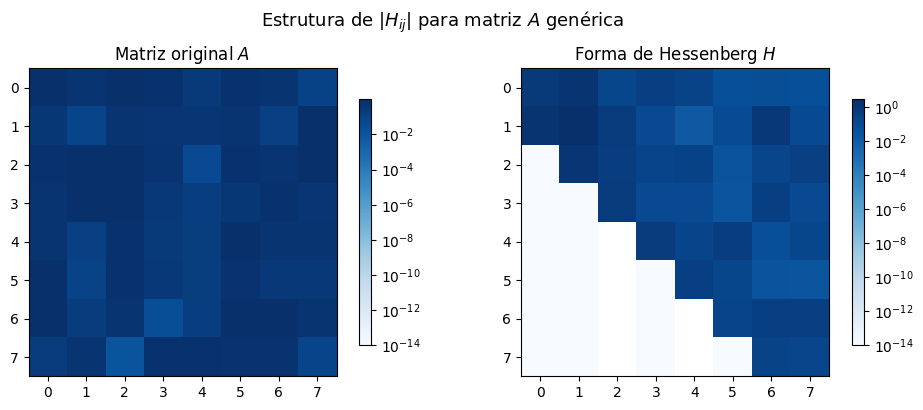

In [87]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

A_vis = rng.random((8, 8))
_, H_vis, _ = to_hessenberg(A_vis)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, M, title in zip(axes, [A_vis, H_vis], ['Matriz original $A$', 'Forma de Hessenberg $H$']):
    im = ax.imshow(np.abs(M), norm=mcolors.LogNorm(vmin=1e-14, vmax=np.abs(M).max()+1e-10),
                   cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Estrutura de $|H_{ij}|$ para matriz $A$ genérica', fontsize=13)
plt.tight_layout()
plt.show()


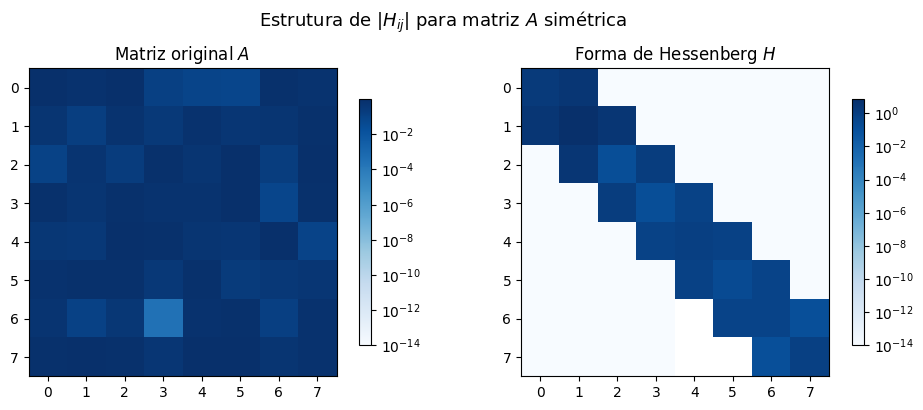

In [ ]:
A_vis = rng.random((8, 8))
A_sim = A_vis + A_vis.T
_, H_vis, _ = to_hessenberg(A_sim)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, M, title in zip(axes, [A_vis, H_vis], ['Matriz original $A$', 'Forma de Hessenberg $H$']):
    im = ax.imshow(np.abs(M), norm=mcolors.LogNorm(vmin=1e-14, vmax=np.abs(M).max()+1e-10),
                   cmap='Blues')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Estrutura de $|H_{ij}|$ para matriz $A$ simétrica', fontsize=13)
plt.tight_layout()
plt.show()

## **Item 2.f** 
**Verifique** que sua função de fato está correta, calculando $\|A - Q H Q^*\|$ e $\|Q^* Q - I\|$ para matrizes simétricas e não simétricas, e de tamanhos 2, 10 e 100.

O que esperamos:

- $\|A - Q H Q^*\| \approx \epsilon_\text{máquina} \cdot \|A\|$ (a decomposição deve ser exata a menos de erros de arredondamento).
- $\|Q^* Q - I\| \approx \epsilon_\text{máquina} \cdot \sqrt{n}$ ($Q$ deve ser numericamente ortogonal).

Os erros crescem com $n$ pois há mais operações acumulando arredondamento, mas devem permanecer na faixa de $O(n \cdot\epsilon_\text{máquina})$.

In [88]:
import pandas as pd

results = []
for n in [2, 5, 10, 50, 100]:
    for label, make_A in [("Simétrica", lambda n: (lambda B: B + B.T)(rng.random((n,n)))),
                          ("Não-simétrica", lambda n: rng.random((n,n)))]:
        A = make_A(n)
        _, H, Q = to_hessenberg(A)
        
        err_decomp = np.linalg.norm(A - Q @ H @ Q.T)
        err_ort   = np.linalg.norm(Q.T @ Q - np.eye(n))
        norm_A     = np.linalg.norm(A)
        rel_err    = err_decomp / norm_A
        
        results.append({'n':n, 'tipo': label, 'err_decomp': err_decomp, 'err_rel':rel_err, 'err_ort': err_ort})

pd.DataFrame(results)

,n,tipo,err_decomp,err_rel,err_ort
0,2,Simétrica,0.000000e+00,0.000000e+00,0.000000e+00
1,2,Não-simétrica,0.000000e+00,0.000000e+00,0.000000e+00
2,5,Simétrica,1.440084e-15,3.144011e-16,1.184743e-15
3,5,Não-simétrica,1.459162e-15,4.814209e-16,8.494660e-16
4,10,Simétrica,4.239976e-15,3.649705e-16,1.349201e-15
5,10,Não-simétrica,2.400783e-15,4.236405e-16,1.421925e-15
6,50,Simétrica,3.030818e-14,5.689888e-16,4.850785e-15
7,50,Não-simétrica,2.438141e-14,8.395741e-16,4.911989e-15
8,100,Simétrica,7.361492e-14,6.772639e-16,8.536798e-15
9,100,Não-simétrica,4.577512e-14,7.942209e-16,9.121370e-15


In [90]:
print("\nVerificação da tridiagonalidade de H para matriz simétrica (os valores devem ser em torno de 0):")

results_sim = []
for n in [5, 10, 20, 50]:
    A_sim = np.random.randn(n, n); A_sim = A_sim + A_sim.T
    _, H_sim, _ = to_hessenberg(A_sim)
    
    # Elementos estritamente acima da superdiagonal
    acima = sum(H_sim[i, j]**2 for i in range(n) for j in range(i+2, n))**0.5
    # Elementos estritamente abaixo da subdiagonal
    abaixo = sum(H_sim[i, j]**2 for i in range(2, n) for j in range(i-1))**0.5
    
    results_sim.append({'n':n, 'acima':acima, 'abaixo':abaixo})

pd.DataFrame(results_sim)


Verificação da tridiagonalidade de H para matriz simétrica (os valores devem ser em torno de 0):


,n,acima,abaixo
0,5,5.087681e-16,4.710277e-16
1,10,2.688318e-15,1.653555e-15
2,20,7.538360e-15,2.826882e-15
3,50,3.143926e-14,1.054886e-14


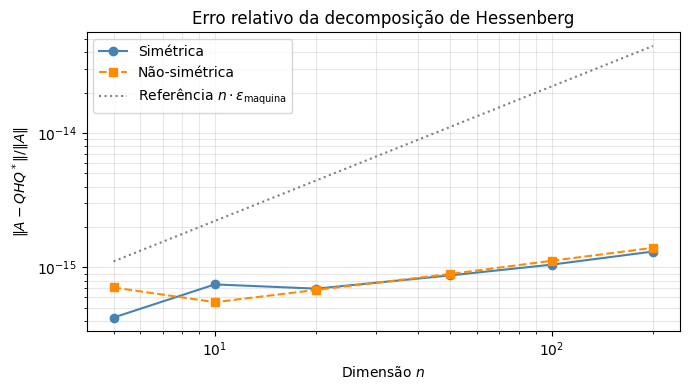

In [ ]:
ns = [5, 10, 20, 50, 100, 200]
errs_sim = []
errs_nao_sim = []

np.random.seed(1)
for n in ns:
    A_s = np.random.randn(n,n)
    A_s = A_s + A_s.T
    A_ns = np.random.randn(n,n)

    _, H_s, Q_s   = to_hessenberg(A_s)
    _, H_ns, Q_ns = to_hessenberg(A_ns)

    errs_sim.append(np.linalg.norm(A_s - Q_s @ H_s @ Q_s.T) / np.linalg.norm(A_s))
    errs_nao_sim.append(np.linalg.norm(A_ns - Q_ns @ H_ns @ Q_ns.T) / np.linalg.norm(A_ns))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ns, errs_sim,    'o-', label='Simétrica', color='steelblue')
ax.loglog(ns, errs_nao_sim, 's--', label='Não-simétrica', color='darkorange')

ref_eps = [np.finfo(float).eps * n for n in ns]
ax.loglog(ns, ref_eps, ':', color='gray', label=r'Referência $n \cdot \epsilon_\mathrm{maquina}$')

ax.set_xlabel('Dimensão $n$')
ax.set_ylabel(r'$\|A - QHQ^*\| / \|A\|$')
ax.set_title('Erro relativo da decomposição de Hessenberg')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()
